# 08 · Raoult's law and flash calculations

The simplest model of a vapour-liquid mixture - Raoult's law, $y_i p = x_i p_i^{sat}$ - already answers the
central questions of distillation and flash separation: at what temperature does a mixture boil, what is
the composition of the first vapour, and how does a partly vaporised feed split between the phases?

**What you will learn**
- compute bubble and dew points with Raoult's law
- read and construct T-x-y and x-y diagrams
- perform isothermal flash calculations with the Rachford-Rice equation
- use relative volatility to judge separations

**Before you start:** notebooks 06-07  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import vapor, vle
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Bubble and dew points
A benzene-toluene mixture (the textbook near-ideal pair) at atmospheric pressure:

In [2]:
p = 101325.0
comps = ["benzene", "toluene"]
for x_b in (0.2, 0.5, 0.8):
    bub = vle.bubble_T(comps, [x_b, 1 - x_b], p)
    dew = vle.dew_T(comps, [x_b, 1 - x_b], p)
    print(f"x_benzene = {x_b}: bubble point {bub['T']-273.15:.1f} degC (first vapour y = {bub['y'][0]:.3f}); "
          f"dew point of a vapour of the same composition {dew['T']-273.15:.1f} degC (first liquid x = {dew['x'][0]:.3f})")
print(f"pure components: benzene boils at {vapor.antoine_Tsat('benzene', p)-273.15:.1f} degC, toluene at {vapor.antoine_Tsat('toluene', p)-273.15:.1f} degC")

x_benzene = 0.2: bubble point 102.1 degC (first vapour y = 0.376); dew point of a vapour of the same composition 106.4 degC (first liquid x = 0.095)
x_benzene = 0.5: bubble point 92.1 degC (first vapour y = 0.714); dew point of a vapour of the same composition 98.8 degC (first liquid x = 0.291)
x_benzene = 0.8: bubble point 84.4 degC (first vapour y = 0.911); dew point of a vapour of the same composition 89.0 degC (first liquid x = 0.613)
pure components: benzene boils at 80.1 degC, toluene at 110.6 degC


The first vapour is richer in benzene, the more volatile component - the effect distillation exploits. A
liquid starts boiling at its bubble point and, if kept at that pressure, is completely vaporised at the dew
point of the same composition; between the two it is a two-phase mixture.

## The T-x-y diagram

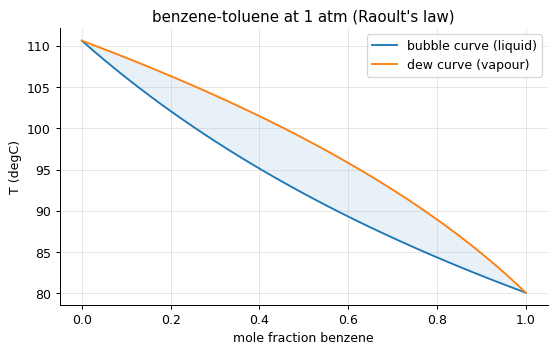

tie line at 92.1 degC: liquid x = 0.500, vapour y = 0.714


In [3]:
d = vle.Txy(comps, p, n=41)
plt.plot(d["x1"], d["T"] - 273.15, label="bubble curve (liquid)"); plt.plot(d["y1"], d["T"] - 273.15, label="dew curve (vapour)")
plt.fill_betweenx(d["T"] - 273.15, d["x1"], d["y1"], alpha=0.1)
plt.xlabel("mole fraction benzene"); plt.ylabel("T (degC)"); plt.title("benzene-toluene at 1 atm (Raoult's law)"); plt.legend(); plt.show()
Tb = vle.bubble_T(comps, [0.5, 0.5], p)["T"]
print(f"tie line at {Tb-273.15:.1f} degC: liquid x = 0.500, vapour y = {vle.bubble_T(comps, [0.5, 0.5], p)['y'][0]:.3f}")

Every horizontal line inside the lens connects a liquid (on the bubble curve) with the vapour in equilibrium
with it (on the dew curve): a **tie line**. The width of the lens is the driving force for separation.

## Relative volatility

relative volatility benzene/toluene at 92 degC: 2.49


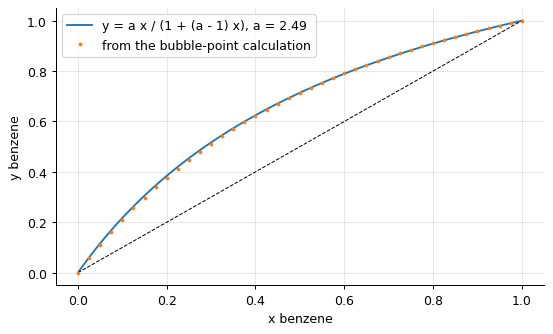

In [4]:
alpha = vapor.antoine_psat("benzene", Tb) / vapor.antoine_psat("toluene", Tb)
print(f"relative volatility benzene/toluene at {Tb-273.15:.0f} degC: {alpha:.2f}")
x = np.linspace(0, 1, 100)
plt.plot(x, alpha * x / (1 + (alpha - 1) * x), label=f"y = a x / (1 + (a - 1) x), a = {alpha:.2f}"); plt.plot(x, x, "k--", lw=0.8)
plt.plot(d["x1"], d["y1"], ".", ms=4, label="from the bubble-point calculation")
plt.xlabel("x benzene"); plt.ylabel("y benzene"); plt.legend(); plt.show()

For an ideal mixture the relative volatility $\alpha = p_1^{sat}/p_2^{sat}$ is nearly constant, and the x-y curve
follows from it alone - the basis of the McCabe-Thiele method for distillation columns. A relative volatility
near 1 means an expensive separation; an azeotrope (notebook 09) means an impossible one.

## The flash drum
A feed is heated and let down to a lower pressure; part of it vaporises. The Rachford-Rice equation gives the
vapour fraction and both compositions:

In [5]:
feed = ["propane", "n-butane", "n-pentane"]
z = [0.3, 0.4, 0.3]
T, p = 320.0, 5e5
fl = vle.flash(feed, z, T, p)
print(f"feed {z} at {T-273.15:.0f} degC and {p/1e5:.0f} bar: vapour fraction {fl['V']:.3f}")
print(pd.DataFrame({"component": feed, "z": z, "x (liquid)": fl["x"], "y (vapour)": fl["y"], "K = y/x": fl["K"]}).round(3).to_string(index=False))
print(f"material balance check z1 = V y1 + (1 - V) x1 = {fl['V']*fl['y'][0] + (1 - fl['V'])*fl['x'][0]:.3f}")

feed [0.3, 0.4, 0.3] at 47 degC and 5 bar: vapour fraction 0.422
component   z  x (liquid)  y (vapour)  K = y/x
  propane 0.3       0.157       0.497    3.172
 n-butane 0.4       0.415       0.380    0.915
n-pentane 0.3       0.429       0.124    0.289
material balance check z1 = V y1 + (1 - V) x1 = 0.300


The vapour concentrates the light propane, the liquid the heavy pentane; the K-values $y_i/x_i$ show each
component's preference. A single flash is a crude separation - a distillation column is a stack of them. How
the split moves with temperature:

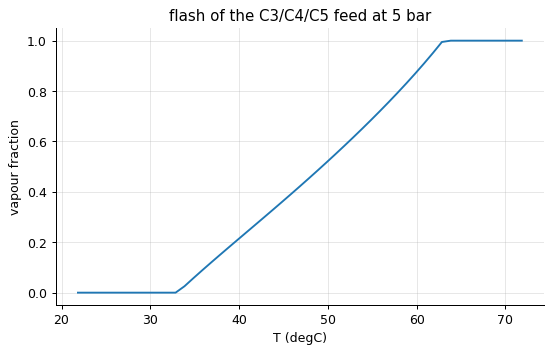

bubble point 33.1 degC, dew point 63.0 degC: the feed is two-phase between them


In [6]:
Ts = np.linspace(295, 345, 51)
V = [vle.flash(feed, z, T, p)["V"] for T in Ts]
plt.plot(Ts - 273.15, V); plt.xlabel("T (degC)"); plt.ylabel("vapour fraction"); plt.title("flash of the C3/C4/C5 feed at 5 bar"); plt.show()
Tb = vle.bubble_T(feed, z, p)["T"]; Td = vle.dew_T(feed, z, p)["T"]
print(f"bubble point {Tb-273.15:.1f} degC, dew point {Td-273.15:.1f} degC: the feed is two-phase between them")

Raoult's law works for mixtures of similar molecules (hydrocarbons of the same family). For unlike molecules -
ethanol and water, acetone and chloroform - the liquid is not ideal, the vapour pressure curves bend, and
azeotropes appear. Notebook 09 adds the activity coefficients that describe them.

## Inside the algorithm: the Rachford-Rice equation
With K-values $K_i = p_i^{sat}/p$, the vapour fraction $V$ solves $\sum_i z_i(K_i - 1)/(1 + V(K_i - 1)) = 0$ - a
monotonic function of $V$, so `brentq` on [0, 1] cannot miss it:

In [7]:
from scipy import optimize
K = np.array([vapor.antoine_psat(c, T) for c in feed]) / p
f = lambda V: np.sum(np.array(z) * (K - 1) / (1 + V * (K - 1)))
V_hand = optimize.brentq(f, 0, 1)
print(f"K-values {np.round(K, 3)}; V by hand {V_hand:.4f}, library {fl['V']:.4f}")

K-values [3.172 0.915 0.289]; V by hand 0.4220, library 0.4220


## Exercises
1. Draw the P-x-y diagram of benzene-toluene at 90 degC. Read off the bubble and dew pressures of an equimolar liquid.
2. A liquefied petroleum gas is 40 % propane and 60 % n-butane (mole). At 20 degC, what is the pressure in a storage vessel, and what is the composition of the vapour above the liquid? How does the vapour composition change as the vessel empties (assume the liquid becomes progressively richer in butane)?
3. **Implement it yourself:** write a bubble-temperature solver from scratch (Raoult's law, Antoine vapour pressures, `brentq` on the sum of $y_i$ minus 1) and reproduce the T-x-y diagram.